In [14]:

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [10]:
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
data = iris.data
labels = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Split the dataset into train and test sets
x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

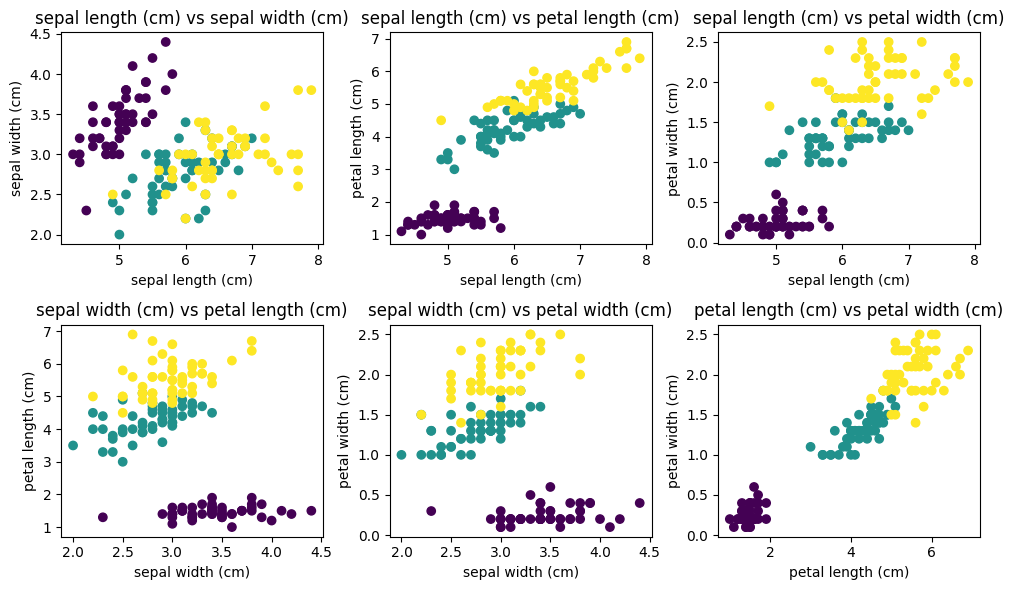

In [12]:
# Create plots for different feature combinations
feature_combinations = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
num_plots = len(feature_combinations)
num_rows = (num_plots + 1) // 3  # Calculate the number of rows required for the subplot grid

# Create the subplot grid
fig, axs = plt.subplots(num_rows, 3, figsize=(10, num_rows * 3))

# Plotting the dataset for each feature combination
for i, (feat_idx1, feat_idx2) in enumerate(feature_combinations):
    row = i // 3  # Determine the row index in the subplot grid
    col = i % 3   # Determine the column index in the subplot grid
    axs[row, col].scatter(data[:, feat_idx1], data[:, feat_idx2], c=labels, cmap='viridis')
    axs[row, col].set_xlabel(feature_names[feat_idx1])
    axs[row, col].set_ylabel(feature_names[feat_idx2])
    axs[row, col].set_title(f"{feature_names[feat_idx1]} vs {feature_names[feat_idx2]}")

plt.tight_layout()
plt.show()

In [15]:
class IrisDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        sample = {
            'features': torch.tensor(self.features[idx], dtype=torch.float32),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }
        return sample

In [18]:
# Create train and test datasets
iris_train_dataset = IrisDataset(x_train, y_train)
iris_test_dataset = IrisDataset(x_test, y_test)

# Create train and test data loaders
iris_train_loader = DataLoader(iris_train_dataset, batch_size=64, shuffle=True)
iris_test_loader = DataLoader(iris_test_dataset, batch_size=64, shuffle=False)

In [57]:
class MyNet(nn.Module):
  def __init__(self):
    super(MyNet, self).__init__()
    self.fc1 = nn.Linear(in_features=4, out_features=64)

    

    self.fc3 = nn.Linear(in_features=64 , out_features=3)

    self.activation = nn.ReLU()
    

  def forward(self, x):
    x = self.fc1(x)
    x = self.activation(x)
    x = self.fc3(x)
      

    return x
     

In [58]:
model = MyNet()
model.to(device)


MyNet(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=3, bias=True)
  (activation): ReLU()
)

In [59]:
criterion = nn.CrossEntropyLoss()

# Hyperparameters

learning_rate = 0.1

epochs = 50
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [60]:
device = torch.device("mps")

In [61]:
def evaluate(model):
  # Put model in evaluation mode
  model.eval()

  # For keeping track of number of correct predictions and total predictions
  correct = 0
  total = 0

  for data in iris_test_loader:
      coords = data['features'].to(device)
      ground_truth = data['label'].to(device)

      # We do not need to keep track of gradients while testing
      with torch.no_grad():
        pred = model(coords)

      # From list of predicted scores we get the class with the highest score
      _, predicted = torch.max(pred, 1)

      # We count all the predictions which match the ground truth to get number of correct predictions
      correct += (predicted == ground_truth).sum().item()
      total += coords.shape[0]

  accuracy = np.round(100 * correct / total, 2)

  print(f"Test Accuracy: {accuracy}")

In [62]:
for epoch in range(epochs):
  model.train()
  epoch_loss = torch.tensor(0.0, device=device)
  for data in iris_train_loader:
    # Put model in training mode
    

    coords = data['features'].to(device)
    ground_truth = data['label'].to(device)
    pred = model(coords)

      
      
    # 2. Compute loss
    loss = criterion(pred, ground_truth)

    # 3. Compute gradients
      
    loss.backward()

    # 4. Update parameters
    optimizer.step()

    # Set gradient to 0 for next computation
    optimizer.zero_grad()

    epoch_loss += loss.detach()

  
  print(f"Epoch: {epoch}, Training loss = {epoch_loss.item()}")
  evaluate(model)    

Epoch: 0, Training loss = 2.3695526123046875
Test Accuracy: 33.33
Epoch: 1, Training loss = 2.2532079219818115
Test Accuracy: 26.67
Epoch: 2, Training loss = 2.176976442337036
Test Accuracy: 16.67
Epoch: 3, Training loss = 2.1242868900299072
Test Accuracy: 16.67
Epoch: 4, Training loss = 2.0791029930114746
Test Accuracy: 16.67
Epoch: 5, Training loss = 2.035426616668701
Test Accuracy: 13.33
Epoch: 6, Training loss = 1.9915095567703247
Test Accuracy: 0.0
Epoch: 7, Training loss = 1.9494850635528564
Test Accuracy: 10.0
Epoch: 8, Training loss = 1.9016549587249756
Test Accuracy: 36.67
Epoch: 9, Training loss = 1.8583736419677734
Test Accuracy: 36.67
Epoch: 10, Training loss = 1.8234699964523315
Test Accuracy: 36.67
Epoch: 11, Training loss = 1.7803230285644531
Test Accuracy: 36.67
Epoch: 12, Training loss = 1.7507754564285278
Test Accuracy: 36.67
Epoch: 13, Training loss = 1.709512710571289
Test Accuracy: 36.67
Epoch: 14, Training loss = 1.6805081367492676
Test Accuracy: 36.67
Epoch: 15, 